Import your dataset and you can start to plan on how to clean and present your data in WordCloud. Happy Coding!

In [ ]:
#import pandas to view your data
import pandas as pd

## How to import data into Colab?




#### From colab folder

Drag/upload your file into colab files directory.

In [ ]:
import pandas as pd
raw_data = pd.read_csv('Rafah.csv')

raw_data.head(5)

,Date,Tweet
0,2024-06-10 13:35:46+00:00,RAFAH💔💔💔\nحسبنا الله ونعم الوكيل.\n#GazaAttack...
1,2024-06-10 13:35:45+00:00,#Rafah #Gaza #Palestine
2,2024-06-10 13:35:40+00:00,"These four civilians, including two children, ..."
3,2024-06-10 13:35:40+00:00,Rafah would not have happened if Hamas txrrist...
4,2024-06-10 13:35:38+00:00,Kha gaye rafah ke liye khoon ke aasun bahane wale


## Prepare our data
You will be focusing only on Tweet column. In this example, you will create a new dataframe called **data_tweet** to store tweet from **raw_data**.

In [ ]:
data_tweet = raw_data[["Tweet"]]

In [ ]:
data_tweet.head(5)

,Tweet
0,RAFAH💔💔💔\nحسبنا الله ونعم الوكيل.\n#GazaAttack...
1,#Rafah #Gaza #Palestine
2,"These four civilians, including two children, ..."
3,Rafah would not have happened if Hamas txrrist...
4,Kha gaye rafah ke liye khoon ke aasun bahane wale


You can inspact data size by using **.shape**

In [ ]:
data_tweet.shape #komen here

(252, 1)

## Import libraries for data cleaning

In [ ]:
pip install unidecode

In [ ]:
!pip install contractions

In [ ]:
# install library to translate multilingual tweets
!pip install langid
import langid

!pip install googletrans==3.1.0a0

In [ ]:
#collapse-hide
# Import libraries and load the data
import numpy as np
import nltk
import re
from nltk.corpus import stopwords
from textblob import TextBlob

# text normalization libraries
import spacy
import unicodedata
from nltk.corpus import wordnet
import collections
import contractions
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer, SnowballStemmer
from nltk.tokenize.toktok import ToktokTokenizer


df = pd.read_csv('Rafah.csv')
data_tweet.head(50)

,Tweet
0,RAFAH💔💔💔\nحسبنا الله ونعم الوكيل.\n#GazaAttack...
1,#Rafah #Gaza #Palestine
2,"These four civilians, including two children, ..."
3,Rafah would not have happened if Hamas txrrist...
4,Kha gaye rafah ke liye khoon ke aasun bahane wale
5,"Hanan is one of over 70,000 Palestinians wound..."
6,i mean her and cong are undeniably toxic as he...
7,Brigade Al Qassam Tekuk Pasukan Israel di Rafa...
8,Can’t believe my eyes. Bollywood celebs who we...
9,@SurabhiMaradiya INSTAGRAM ALLOWED THE HASTAGS...


### Clean your data

1. Remove links

In [ ]:
data_tweet['link_removed'] = data_tweet.apply(lambda row: re.sub(r"http\S+|www.\S+","", row['Tweet']),axis=1)
data_tweet[['Tweet','link_removed']].head(50)

,Tweet,link_removed
0,RAFAH💔💔💔\nحسبنا الله ونعم الوكيل.\n#GazaAttack...,RAFAH💔💔💔\nحسبنا الله ونعم الوكيل.\n#GazaAttack...
1,#Rafah #Gaza #Palestine,#Rafah #Gaza #Palestine
2,"These four civilians, including two children, ...","These four civilians, including two children, ..."
3,Rafah would not have happened if Hamas txrrist...,Rafah would not have happened if Hamas txrrist...
4,Kha gaye rafah ke liye khoon ke aasun bahane wale,Kha gaye rafah ke liye khoon ke aasun bahane wale
5,"Hanan is one of over 70,000 Palestinians wound...","Hanan is one of over 70,000 Palestinians wound..."
6,i mean her and cong are undeniably toxic as he...,i mean her and cong are undeniably toxic as he...
7,Brigade Al Qassam Tekuk Pasukan Israel di Rafa...,Brigade Al Qassam Tekuk Pasukan Israel di Rafa...
8,Can’t believe my eyes. Bollywood celebs who we...,Can’t believe my eyes. Bollywood celebs who we...
9,@SurabhiMaradiya INSTAGRAM ALLOWED THE HASTAGS...,@SurabhiMaradiya INSTAGRAM ALLOWED THE HASTAGS...


2. Translate multilingual tweets into English language

In [ ]:
import googletrans
from googletrans import Translator

translator = Translator()
def translate_tweet(tweet):
    try:
        lang = langid.classify(tweet)[0]
        if lang != 'en':
            return translator.translate(tweet, dest='en').text
        return tweet
    except Exception as e:
        print(f"Error translating tweet: {e}")
        return tweet

# Apply the translation function to each tweet in the DataFrame
data_tweet['translate_tweet'] = data_tweet['link_removed'].apply(translate_tweet)

# Display the first 30 translated tweets
data_tweet.head(50)

,Tweet,link_removed,translate_tweet
0,RAFAH💔💔💔\nحسبنا الله ونعم الوكيل.\n#GazaAttack...,RAFAH💔💔💔\nحسبنا الله ونعم الوكيل.\n#GazaAttack...,"RAFAH💔💔💔\nGod is enough, and yes, the agent.\n..."
1,#Rafah #Gaza #Palestine,#Rafah #Gaza #Palestine,#Rafah #Gaza #Palestine
2,"These four civilians, including two children, ...","These four civilians, including two children, ...","These four civilians, including two children, ..."
3,Rafah would not have happened if Hamas txrrist...,Rafah would not have happened if Hamas txrrist...,Rafah would not have happened if Hamas txrrist...
4,Kha gaye rafah ke liye khoon ke aasun bahane wale,Kha gaye rafah ke liye khoon ke aasun bahane wale,Those who shed tears of blood for the eaten Rafah
5,"Hanan is one of over 70,000 Palestinians wound...","Hanan is one of over 70,000 Palestinians wound...","Hanan is one of over 70,000 Palestinians wound..."
6,i mean her and cong are undeniably toxic as he...,i mean her and cong are undeniably toxic as he...,i mean her and cong are undeniably toxic as he...
7,Brigade Al Qassam Tekuk Pasukan Israel di Rafa...,Brigade Al Qassam Tekuk Pasukan Israel di Rafa...,Al Qassam Brigades Defeat Israeli Troops in Ra...
8,Can’t believe my eyes. Bollywood celebs who we...,Can’t believe my eyes. Bollywood celebs who we...,Can’t believe my eyes. Bollywood celebs who we...
9,@SurabhiMaradiya INSTAGRAM ALLOWED THE HASTAGS...,@SurabhiMaradiya INSTAGRAM ALLOWED THE HASTAGS...,@SurabhiMaradiya INSTAGRAM ALLOWED THE HASHTAG...


Remove hashtags and mentions

In [ ]:
# Remove mentions from 'text_lowered'
data_tweet['text_removed'] = data_tweet.apply(lambda row: re.sub(r"@[A-Za-z0-9_]+", "", row['translate_tweet']), axis=1)

# Remove hashtags symbols but keep the words attached to them
data_tweet['text_removed'] = data_tweet.apply(lambda row: re.sub(r"#", "", row['text_removed']), axis=1)

# Display the first few rows of 'text_lowered' and 'text_removed' columns
data_tweet[['translate_tweet', 'text_removed']].head(50)

,translate_tweet,text_removed
0,"RAFAH💔💔💔\nGod is enough, and yes, the agent.\n...","RAFAH💔💔💔\nGod is enough, and yes, the agent.\n..."
1,#Rafah #Gaza #Palestine,Rafah Gaza Palestine
2,"These four civilians, including two children, ...","These four civilians, including two children, ..."
3,Rafah would not have happened if Hamas txrrist...,Rafah would not have happened if Hamas txrrist...
4,Those who shed tears of blood for the eaten Rafah,Those who shed tears of blood for the eaten Rafah
5,"Hanan is one of over 70,000 Palestinians wound...","Hanan is one of over 70,000 Palestinians wound..."
6,i mean her and cong are undeniably toxic as he...,i mean her and cong are undeniably toxic as he...
7,Al Qassam Brigades Defeat Israeli Troops in Ra...,Al Qassam Brigades Defeat Israeli Troops in Ra...
8,Can’t believe my eyes. Bollywood celebs who we...,Can’t believe my eyes. Bollywood celebs who we...
9,@SurabhiMaradiya INSTAGRAM ALLOWED THE HASHTAG...,INSTAGRAM ALLOWED THE HASHTAGS ON RAFAH BUT B...


Normalize texts and lowercase

In [ ]:
from unidecode import unidecode
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

wnl = WordNetLemmatizer()
nltk.download('punkt')
nltk.download('wordnet')

# initialize lemmatizer and stemmer
lemmatizer = WordNetLemmatizer()

# no use for stemmer because it changes the initial word and can be taken out of context

def normalize_text(text):
    text = unidecode(text)
    # expand contractions
    text = contractions.fix(text)
    # tokenize text
    words = nltk.word_tokenize(text)
    # lemmatize without POS tagging for simplicity
    words = [lemmatizer.lemmatize(word) for word in words]
    # Join words back into a single string
    return ' '.join(words)

# apply normalization to 'Tweet' column and store the result in 'normalized_tweet'
data_tweet['normalized_tweet'] = data_tweet['text_removed'].apply(normalize_text)
data_tweet['text_lowered'] = data_tweet.apply(lambda row: row['normalized_tweet'].lower(),axis=1)
data_tweet[['text_removed','text_lowered']].head(50)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,text_removed,text_lowered
0,"RAFAH💔💔💔\nGod is enough, and yes, the agent.\n...","rafah god is enough , and yes , the agent . ga..."
1,Rafah Gaza Palestine,rafah gaza palestine
2,"These four civilians, including two children, ...","these four civilian , including two child , we..."
3,Rafah would not have happened if Hamas txrrist...,rafah would not have happened if hamas txrrist...
4,Those who shed tears of blood for the eaten Rafah,those who she would tear of blood for the eate...
5,"Hanan is one of over 70,000 Palestinians wound...","hanan is one of over 70,000 palestinians wound..."
6,i mean her and cong are undeniably toxic as he...,i mean her and cong are undeniably toxic a hel...
7,Al Qassam Brigades Defeat Israeli Troops in Ra...,al qassam brigades defeat israeli troops in ra...
8,Can’t believe my eyes. Bollywood celebs who we...,can not believe my eye . bollywood celebs who ...
9,INSTAGRAM ALLOWED THE HASHTAGS ON RAFAH BUT B...,instagram allowed the hashtags on rafah but ba...


Stopword removal

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# Exclude stopwords with Python's list comprehension and pandas.DataFrame.apply.
data_tweet['remove_stopwords'] = data_tweet['text_lowered'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))
data_tweet[['text_lowered','remove_stopwords']].head(50)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,text_lowered,remove_stopwords
0,"rafah god is enough , and yes , the agent . ga...","rafah god enough , yes , agent . gazaattack ce..."
1,rafah gaza palestine,rafah gaza palestine
2,"these four civilian , including two child , we...","four civilian , including two child , killed i..."
3,rafah would not have happened if hamas txrrist...,rafah would happened hamas txrrist attacked is...
4,those who she would tear of blood for the eate...,would tear blood eaten rafah
5,"hanan is one of over 70,000 palestinians wound...","hanan one 70,000 palestinians wounded israeli ..."
6,i mean her and cong are undeniably toxic a hel...,"mean cong undeniably toxic hell , ( idc anyone..."
7,al qassam brigades defeat israeli troops in ra...,al qassam brigades defeat israeli troops rafah...
8,can not believe my eye . bollywood celebs who ...,believe eye . bollywood celebs talking rafah f...
9,instagram allowed the hashtags on rafah but ba...,instagram allowed hashtags rafah banned hastag...


Filter non-alphanumeric characters

In [ ]:
data_tweet['clean_data'] = data_tweet.apply(lambda row: re.sub("[^a-z0-9]"," ", row['remove_stopwords']),axis=1)
data_tweet[['remove_stopwords','clean_data']].head(50)

,remove_stopwords,clean_data
0,"rafah god enough , yes , agent . gazaattack ce...",rafah god enough yes agent gazaattack ce...
1,rafah gaza palestine,rafah gaza palestine
2,"four civilian , including two child , killed i...",four civilian including two child killed i...
3,rafah would happened hamas txrrist attacked is...,rafah would happened hamas txrrist attacked is...
4,would tear blood eaten rafah,would tear blood eaten rafah
5,"hanan one 70,000 palestinians wounded israeli ...",hanan one 70 000 palestinians wounded israeli ...
6,"mean cong undeniably toxic hell , ( idc anyone...",mean cong undeniably toxic hell idc anyone...
7,al qassam brigades defeat israeli troops rafah...,al qassam brigades defeat israeli troops rafah...
8,believe eye . bollywood celebs talking rafah f...,believe eye bollywood celebs talking rafah f...
9,instagram allowed hashtags rafah banned hastag...,instagram allowed hashtags rafah banned hastag...


In [ ]:
clean_data_df = pd.DataFrame(data_tweet['clean_data'])
clean_data_df.head(50)

,clean_data
0,rafah god enough yes agent gazaattack ce...
1,rafah gaza palestine
2,four civilian including two child killed i...
3,rafah would happened hamas txrrist attacked is...
4,would tear blood eaten rafah
5,hanan one 70 000 palestinians wounded israeli ...
6,mean cong undeniably toxic hell idc anyone...
7,al qassam brigades defeat israeli troops rafah...
8,believe eye bollywood celebs talking rafah f...
9,instagram allowed hashtags rafah banned hastag...


Handle missing data: drop missing values in rows

In [ ]:
# Count rows with NaN values
nan_count = clean_data_df['clean_data'].isna().sum()

# Count rows that are empty or contain only whitespace
empty_or_whitespace_count = (clean_data_df['clean_data'].str.strip() == '').sum()

# Count valid rows (non-NaN and non-empty/whitespace)
valid_count = len(clean_data_df) - (nan_count + empty_or_whitespace_count)

# Print the counts
print(f"Count of NaN rows: {nan_count}")
print(f"Count of empty or whitespace rows: {empty_or_whitespace_count}")
print(f"Count of valid rows: {valid_count}")

Count of NaN rows: 0
Count of empty or whitespace rows: 3
Count of valid rows: 249


In [ ]:
# drop rows that are empty, contain only whitespace
clean_data_df = clean_data_df[clean_data_df['clean_data'].str.strip() != '']

# Reset the index
clean_data_df.reset_index(drop=True, inplace=True)

In [ ]:
# Recalculate the counts after dropping rows
nan_count = clean_data_df['clean_data'].isna().sum()
empty_or_whitespace_count = (clean_data_df['clean_data'].str.strip() == '').sum()
valid_count = len(clean_data_df) - (nan_count + empty_or_whitespace_count)

# Print the counts
print(f"Count of NaN rows: {nan_count}")
print(f"Count of empty or whitespace rows: {empty_or_whitespace_count}")
print(f"Count of valid rows: {valid_count}")

Count of NaN rows: 0
Count of empty or whitespace rows: 0
Count of valid rows: 249


In [ ]:
clean_data_df = pd.DataFrame(data_tweet['clean_data'])
clean_data_df

,clean_data
0,rafah god enough yes agent gazaattack ce...
1,rafah gaza palestine
2,four civilian including two child killed i...
3,rafah would happened hamas txrrist attacked is...
4,would tear blood eaten rafah
...,...
247,
248,israeli occupation continues close rafah...
249,oh yes ready tomorrow morning shower dress...
250,geemessssssssss


### Use WordCloud to present your data (Raw and Clean Data). Describ

WordCloud: raw data

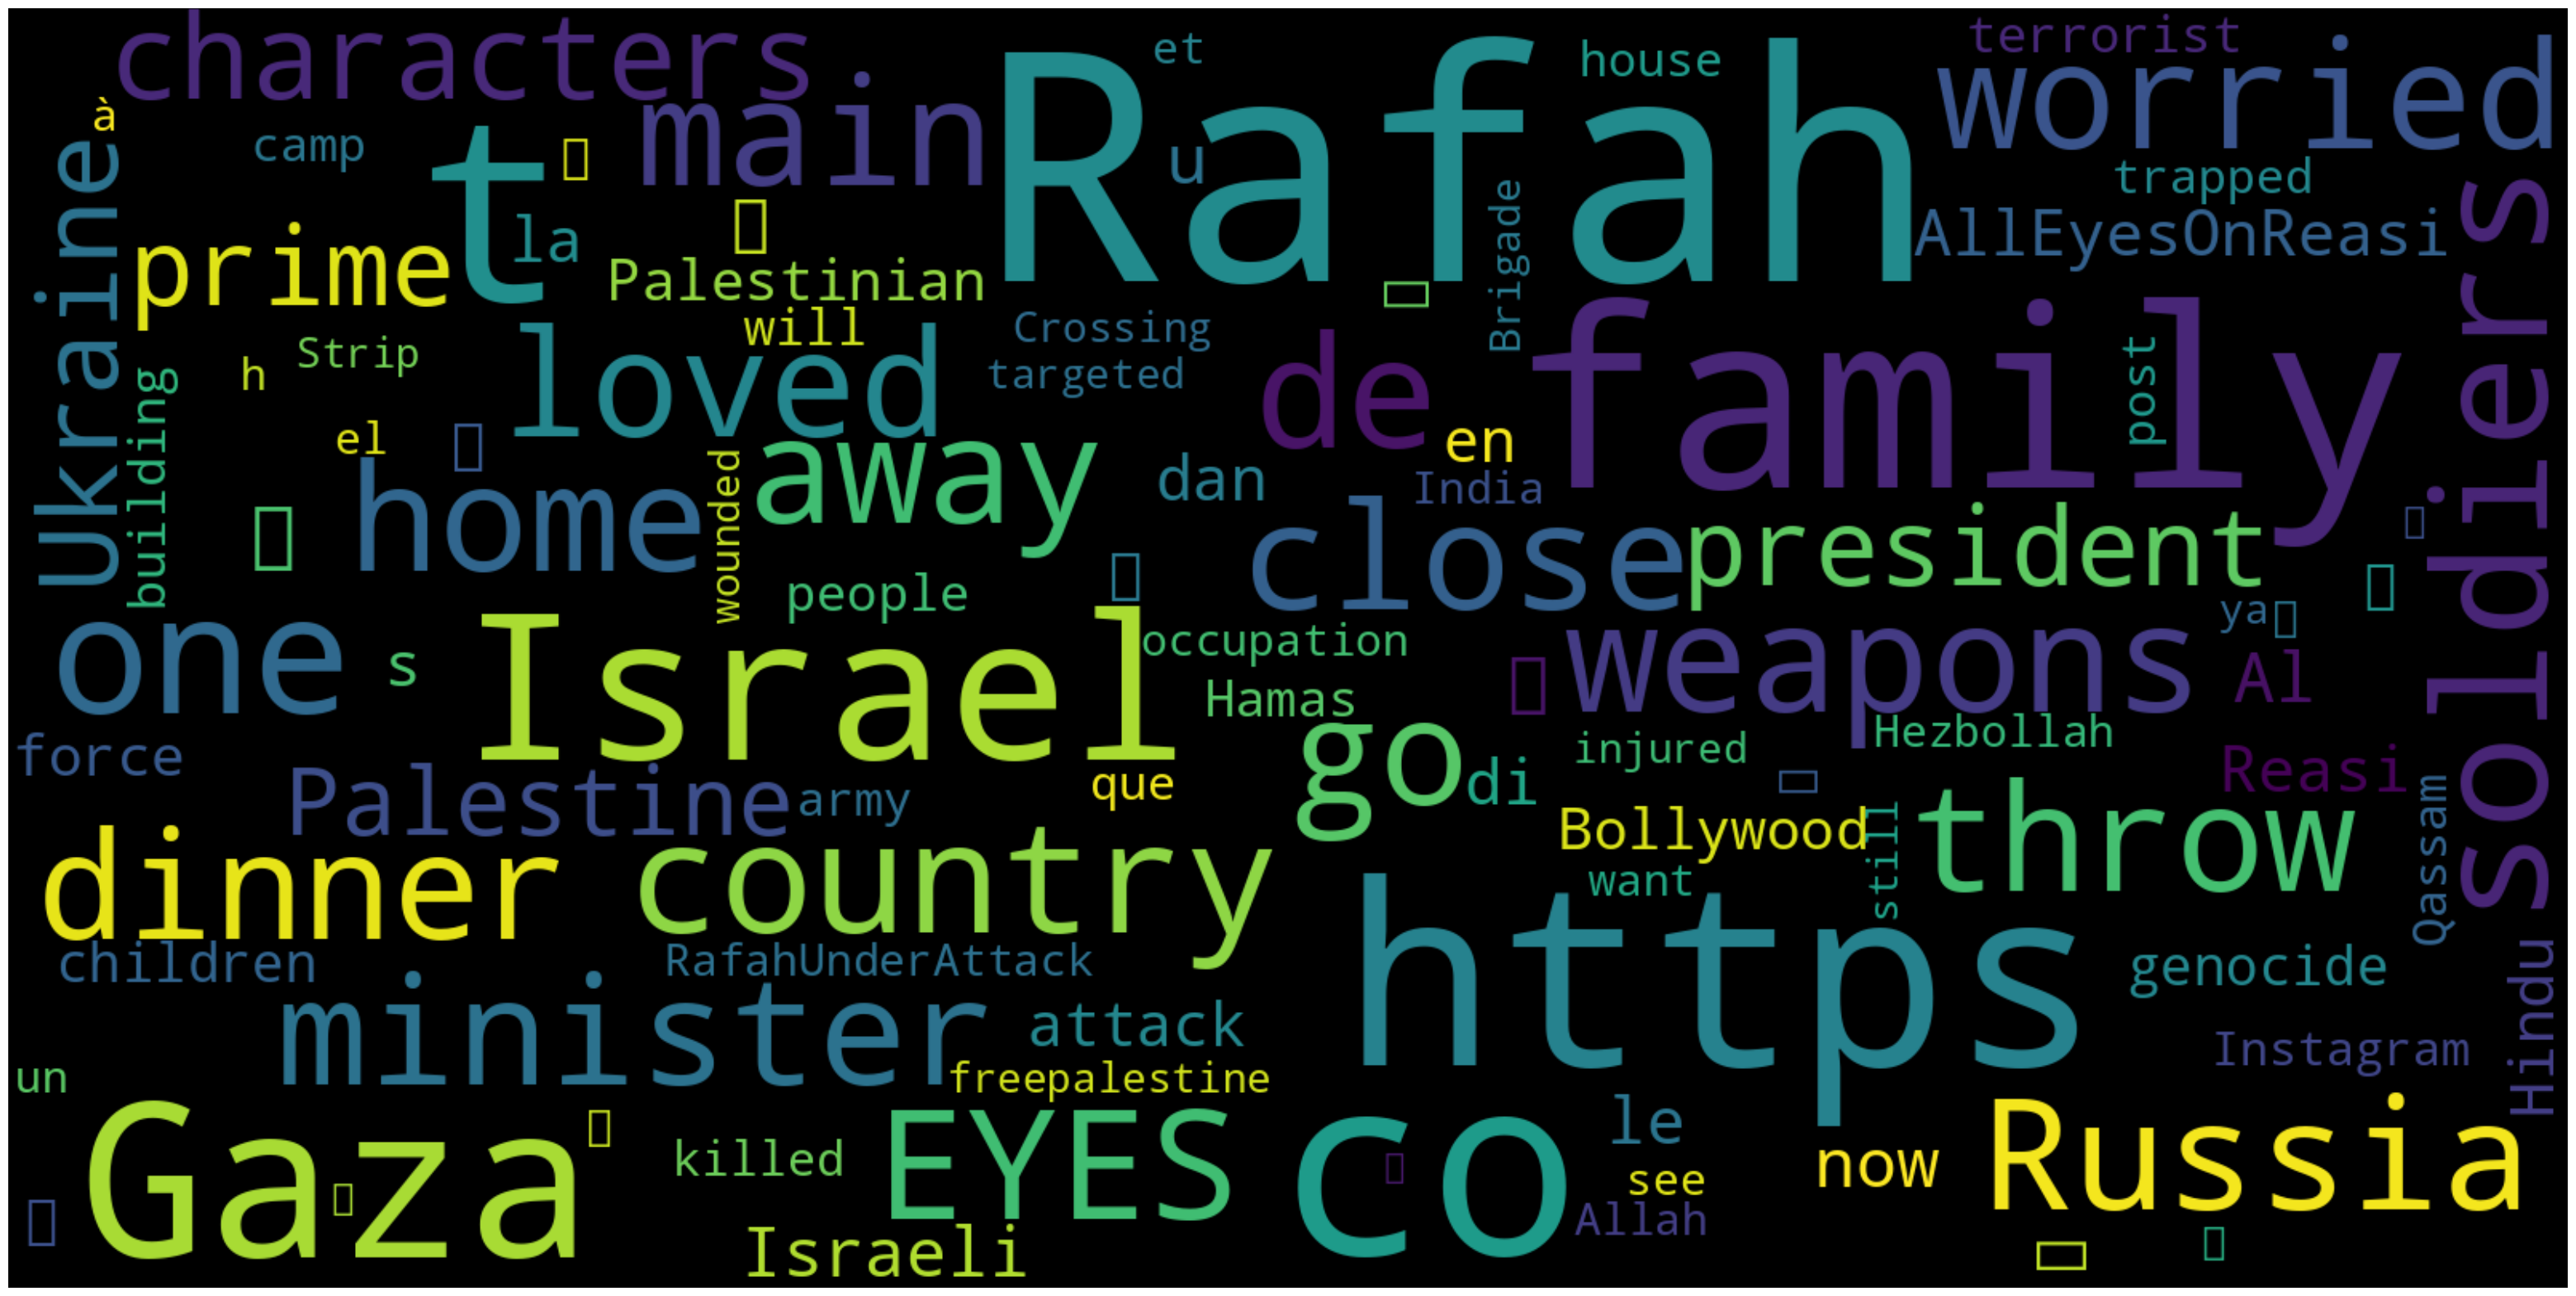

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

raw_data = data_tweet['Tweet']
# convert raw_data to string format
raw_text = ' '.join(raw_data.astype(str))
string = pd.Series(raw_data).str.cat(sep=' ')
raw_wordcloud = WordCloud(width=1600, stopwords=set(STOPWORDS),height=800,max_font_size=200,max_words=100,collocations=False, background_color='black').generate(raw_text)
plt.figure(figsize=(40,30))
plt.imshow(raw_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

WordCloud: cleaned data

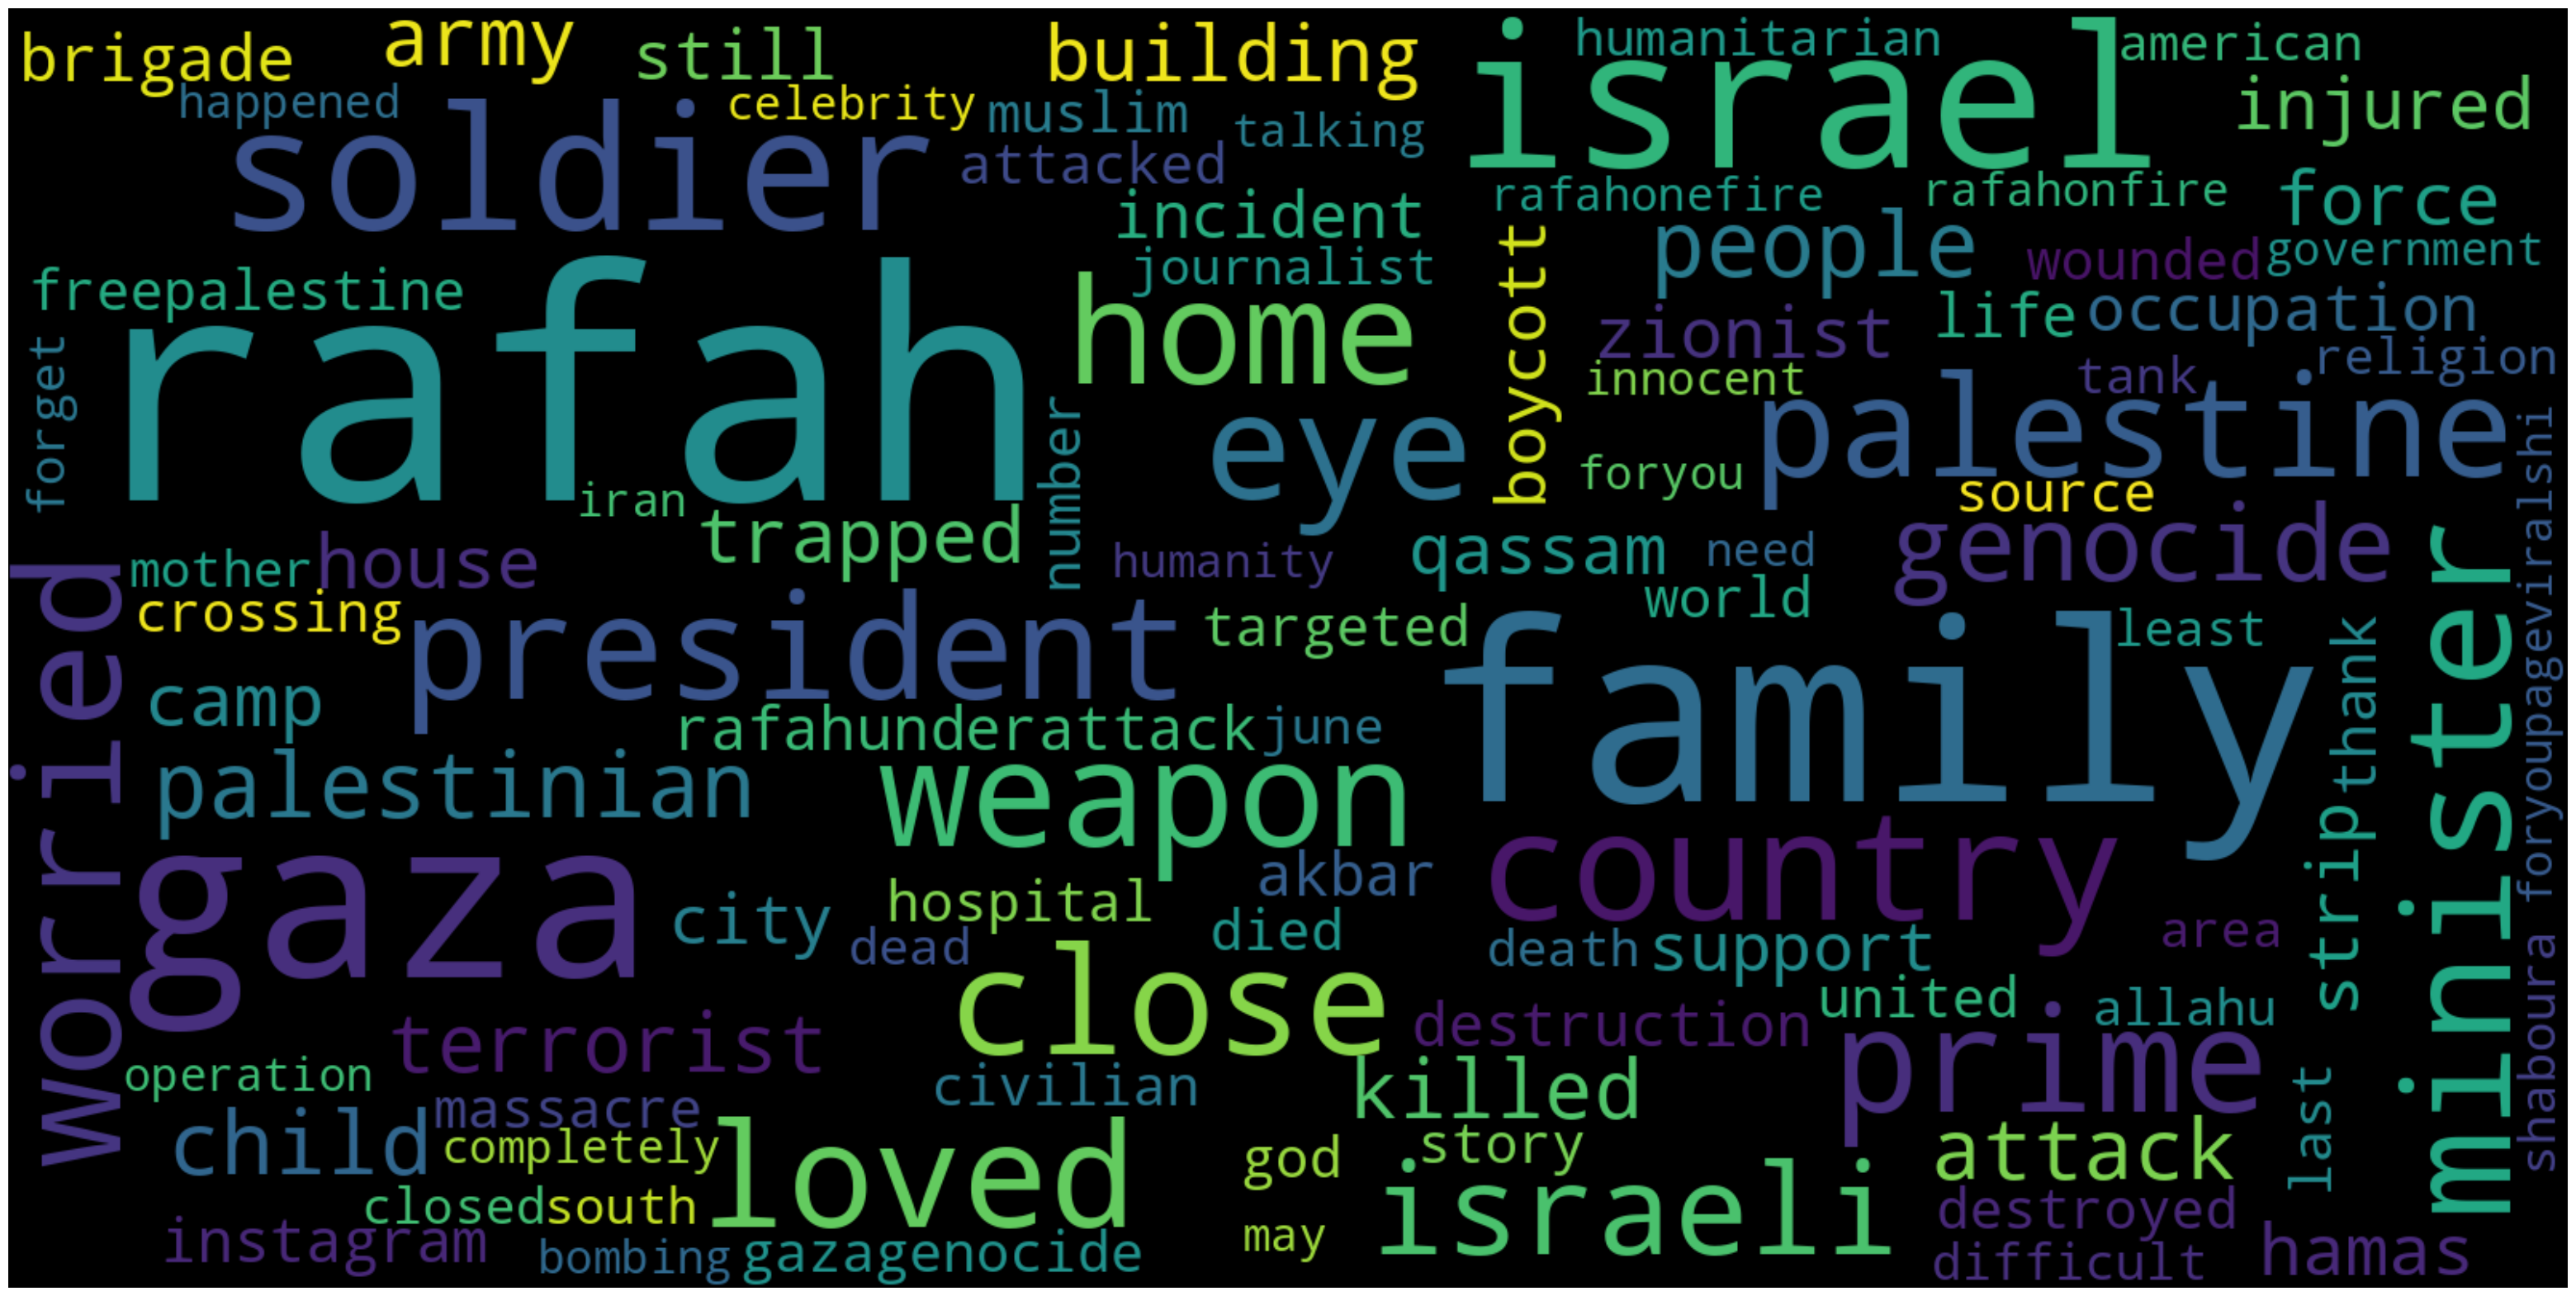

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

clean_data = clean_data_df['clean_data']
# convert raw_data to string format
clean_text = ' '.join(clean_data.astype(str))
string = pd.Series(clean_data).str.cat(sep=' ')
stopwords = set(STOPWORDS)
stopwords.update(['point','booby','dinner','hindu','hindus','hebrew','alleyesonreasi','reasi','characters','bollywood','ukraine','russia','hezbollah','going','al','link','us','czennie','go','s','ye','nct','ha','right','two','come','one','wa','u','say','said','take','india','character','want','main','throw','back','day','starbucks','away','see','new','indian','nhi','kyu','let','pakistan','inside','sm','really','know','yes','post','doe','put']) #adding our own stopwords
raw_wordcloud = WordCloud(width=1600, stopwords=stopwords,height=800,max_font_size=200,max_words=100,collocations=False, background_color='black').generate(clean_text)
plt.figure(figsize=(40,30))
plt.imshow(raw_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()